In [3]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import xarray as xr
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import glob
sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.align import align_to_reference_time

In [4]:
# Cell 2 — Load both
def load_rpg(folder):
    files = sorted(glob.glob(str(Path(folder) / "*ZEN.LV1.nc")))
    ds = xr.open_mfdataset(files, combine="by_coords")
    epoch = pd.Timestamp("2001-01-01")
    ds = ds.assign_coords(Time=("Time", epoch + pd.to_timedelta(ds.Time.values, unit="s")))
    ds = drop_duplicate_times(ds)
    return ds

ds_w  = load_rpg("../data/raw/cmtrace/20230928")
ds_ka = load_rpg("../data/raw/cmtrace/20230928_KaBand")

C:\Users\geron\AppData\Local\Temp\ipykernel_16724\1571843587.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds = ds.assign_coords(Time=("Time", epoch + pd.to_timedelta(ds.Time.values, unit="s")))
C:\Users\geron\AppData\Local\Temp\ipykernel_16724\1571843587.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 

In [5]:
# Cell 3 — Reflectivities
ze_w  = get_reflectivity(ds_w)
ze_ka = get_reflectivity(ds_ka)

In [6]:
# Cell 4 — Inspect ranges
print(f"W : {ze_w['range'].values[0]:.1f} → {ze_w['range'].values[-1]:.1f} m  ({ze_w.sizes['range']} gates)")
print(f"Ka: {ze_ka['range'].values[0]:.1f} → {ze_ka['range'].values[-1]:.1f} m  ({ze_ka.sizes['range']} gates)")
identical = np.allclose(ze_w['range'].values, ze_ka['range'].values)
print(f"Ranges identical: {identical}")

W : 111.8 → 11974.8 m  (339 gates)
Ka: 111.8 → 11974.8 m  (339 gates)
Ranges identical: True


In [7]:
print("Ka samples:", ze_ka.sizes["Time"])
print("W samples :", ze_w.sizes["Time"])

print("Ka start:", ze_ka.Time.values[0])
print("W start :", ze_w.Time.values[0])

print("Ka end  :", ze_ka.Time.values[-1])
print("W end   :", ze_w.Time.values[-1])

Ka samples: 10520
W samples : 10441
Ka start: 2023-09-28T07:00:04.000000000
W start : 2023-09-28T07:00:04.000000000
Ka end  : 2023-09-28T14:00:32.000000000
W end   : 2023-09-28T14:00:32.000000000


In [8]:
common = np.intersect1d(
    ze_ka.Time.values,
    ze_w.Time.values
)

print("Common timestamps:", len(common))
print("Ka timestamps    :", len(ze_ka.Time))
print("W timestamps     :", len(ze_w.Time))

Common timestamps: 10441
Ka timestamps    : 10520
W timestamps     : 10441


In [9]:
print(
    (ze_ka.Time.diff("Time") / np.timedelta64(1, "s"))
    .median()
    .values
)

print(
    (ze_w.Time.diff("Time") / np.timedelta64(1, "s"))
    .median()
    .values
)

1.0
1.0


In [ ]:
# Cell 5 — Common time grid

# ze_w_c = align_to_reference_time(
    #da_ref=ze_ka,
    #da_target=ze_w,
    #method="nearest"
#)

#ze_ka_c = ze_ka

In [ ]:
# Cell 6 — Range alignment (only if not identical)
#if not identical:
 # ze_ka_c = ze_ka_c.interp(range=ze_w_c["range"])

In [11]:
ze_ka_c = ze_ka.sel(Time=ze_w.Time)
ze_w_c = ze_w

In [12]:
# Cell 7 — Verify
print(f"After alignment: W={ze_w_c.shape}, Ka={ze_ka_c.shape}")
assert ze_w_c.shape == ze_ka_c.shape, "Shapes still don't match!"
print("✅ Aligned on common (time, range) grid")

After alignment: W=(10441, 339), Ka=(10441, 339)
✅ Aligned on common (time, range) grid


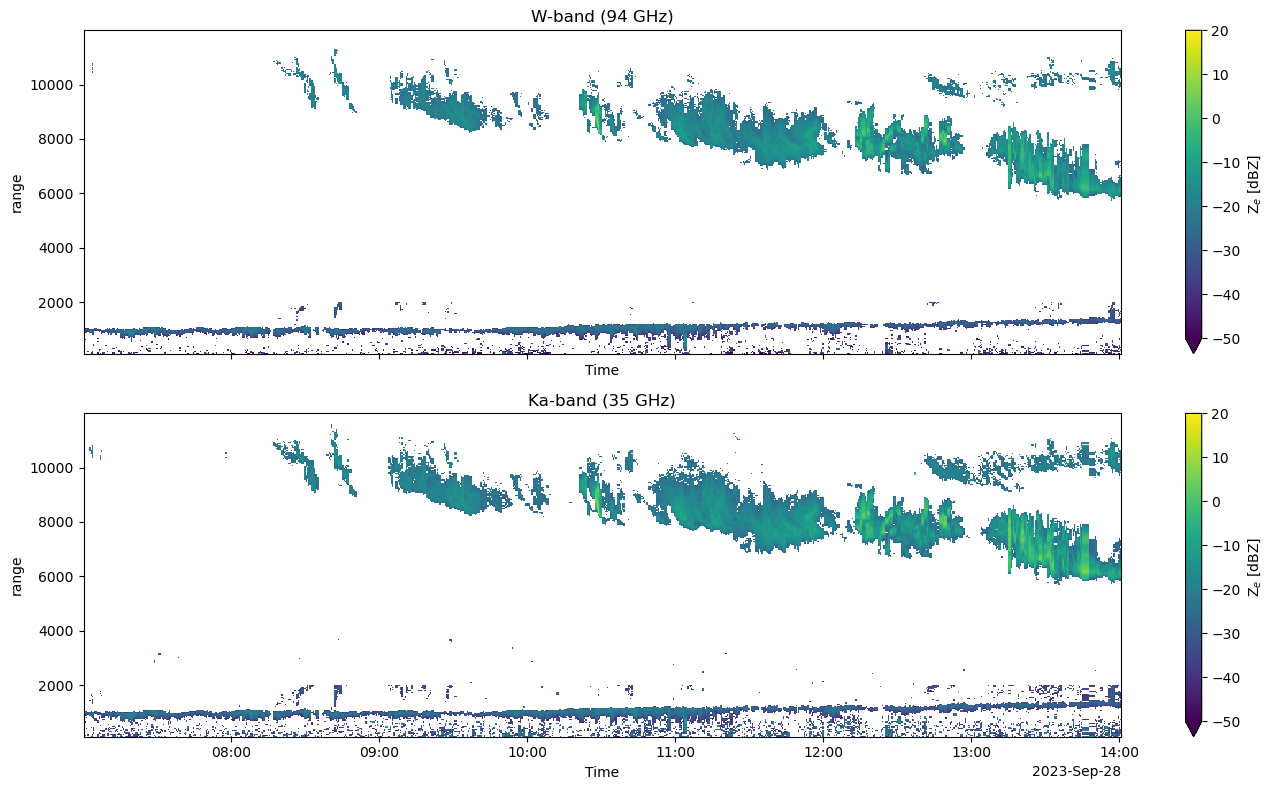

In [13]:
# Cell 8 — Side-by-side plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)
ze_w_c.plot(x="Time", y="range", ax=axes[0], cmap="viridis", vmin=-50, vmax=20, cbar_kwargs={"label": "Z$_e$ [dBZ]"})
axes[0].set_title("W-band (94 GHz)")
ze_ka_c.plot(x="Time", y="range", ax=axes[1], cmap="viridis", vmin=-50, vmax=20, cbar_kwargs={"label": "Z$_e$ [dBZ]"})
axes[1].set_title("Ka-band (35 GHz)")
plt.tight_layout()
plt.show()

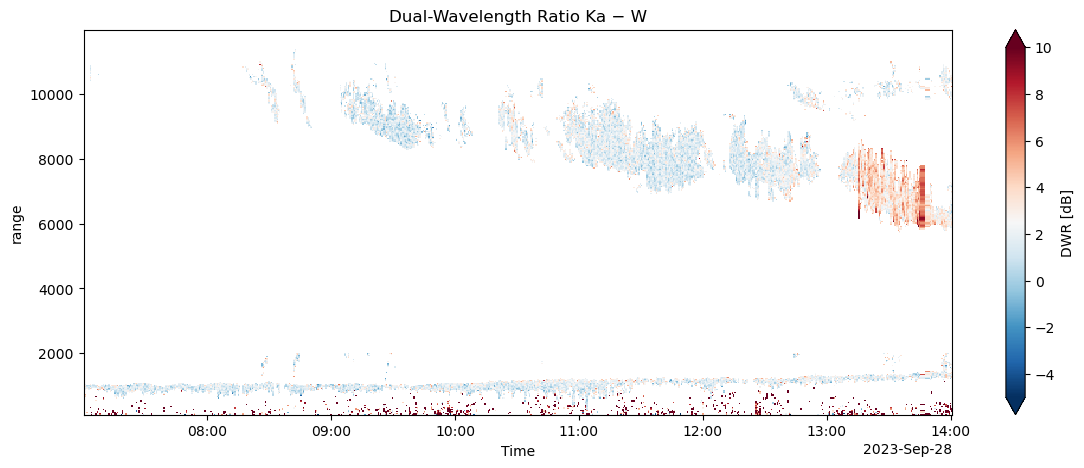

In [14]:
# Cell 9 — Sneak peek at DWR!
dwr = ze_ka_c - ze_w_c   # in dB
dwr.name = "DWR"
dwr.attrs["units"] = "dB"
fig, ax = plt.subplots(figsize=(14, 5))
dwr.plot(x="Time", y="range", cmap="RdBu_r", vmin=-5, vmax=10, ax=ax, cbar_kwargs={"label": "DWR [dB]"})
ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

Looking for masks to Put. (Temperature above 0 Degrees/ dBZ< 40 dBZ disregarded?/ Ceilometer available for cloud base)  Didnt look into Doppler Velocity difference between W and K Band so far

In [17]:
np.diff(ze_w["range"].values)[:10]

array([22.359085, 22.35907 , 22.359085, 22.359085, 22.35907 , 22.359085,
       22.359085, 22.35907 , 22.35907 , 22.3591  ], dtype=float32)

In [18]:
print(ds_w["TProf"])

<xarray.DataArray 'TProf' (Time: 10441, TAlt: 93)> Size: 4MB
dask.array<getitem, shape=(10441, 93), dtype=float32, chunksize=(78, 93), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
Dimensions without coordinates: TAlt
Attributes:
    Name:     Temperature profiles from RPG radiometer
    Units:    K


In [19]:
print(float(ze_ka.min()))
print(float(ze_ka.max()))

print(float(ze_w.min()))
print(float(ze_w.max()))

-58.842552185058594
11.43195629119873
-60.44513702392578
8.699618339538574


(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 4.0000e+00, 3.0000e+00,
        4.0000e+00, 1.5000e+01, 5.0000e+00, 6.0000e+00, 1.1000e+01,
        1.9000e+01, 3.0000e+01, 3.3000e+01, 4.8000e+01, 1.2800e+02,
        3.9900e+02, 8.0400e+02, 1.3650e+03, 2.1560e+03, 3.0060e+03,
        3.9810e+03, 4.7200e+03, 5.5470e+03, 6.1360e+03, 6.5760e+03,
        7.2160e+03, 7.2030e+03, 7.2920e+03, 7.1780e+03, 7.0740e+03,
        6.7960e+03, 6.7490e+03, 6.6410e+03, 6.5770e+03, 6.8460e+03,
        6.8310e+03, 7.2410e+03, 8.0030e+03, 8.8160e+03, 9.9230e+03,
        1.1528e+04, 1.3329e+04, 1.5657e+04, 1.7927e+04, 1.9538e+04,
        2.0238e+04, 2.0058e+04, 1.8738e+04, 1.7327e+04, 1.6038e+04,
        1.4390e+04, 1.3583e+04, 1.2888e+04, 1.2159e+04, 1.1284e+04,
        1.0759e+04, 1.0105e+04, 9.6920e+03, 9.3920e+03, 8.5110e+03,
        7.7640e+03, 6.5390e+03, 5.2700e+03, 4.6230e+03, 3.8790e+03,
        3.5570e+03, 3.1360e+03, 2.8520e+03, 2.38

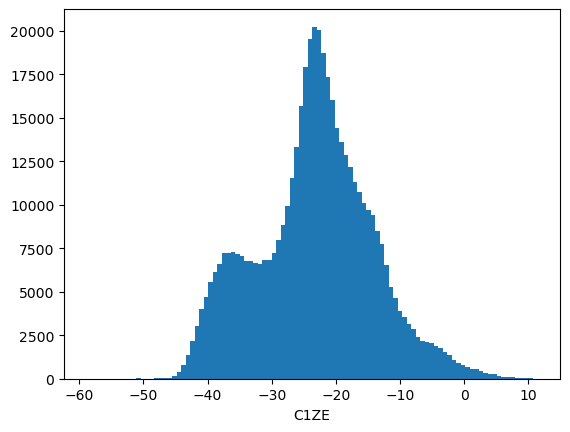

In [20]:
ze_ka.plot.hist(bins=100)

In [23]:
T = ds_w["TProf"]                     # whatever the variable is named
print("Shape:", T.shape)                 # (Time, TAlt)?
print("Dims:", T.dims)
print("Min/Max:", float(T.min()), float(T.max()))
print("First profile (first time, all altitudes):")
print(T.isel(Time=0).values)
print("Altitude coord (if any):")
print(ds_w.coords)  # look for TAltLayer or similar


Shape: (10441, 93)
Dims: ('Time', 'TAlt')
Min/Max: 224.45999145507812 292.6600036621094
First profile (first time, all altitudes):
[289.46    289.395   289.2975  289.13498 288.9725  288.81    288.615
 288.41998 288.225   288.03    287.835   287.63998 287.44498 287.25
 287.055   286.86    286.66498 286.47    286.275   286.08    285.81998
 285.56    285.3     285.03998 284.78    284.52    284.25998 284.
 283.74    283.47998 283.22    282.96    282.69998 282.44    282.18
 281.91998 281.66    281.27    280.88    280.49    280.1     279.71
 279.31998 278.93    278.53998 278.15    277.75998 277.175   276.59
 275.35498 274.77    274.185   273.66498 273.21    272.56    271.91
 271.25998 270.61    269.96    269.31    268.66    268.00998 267.36
 266.71    265.735   264.75998 263.785   262.81    261.835   260.86
 259.88498 259.56    258.25998 256.96    255.65999 254.35999 253.06
 251.76    250.45999 248.51    246.56    244.60999 242.65999 240.70999
 238.76    236.81    234.85999 232.90999 230.959